# Movie Review (MultinomialNB)

In [1]:
import pandas as pd
from sklearn.naive_bayes import MultinomialNB
from sklearn.feature_extraction.text import CountVectorizer

In [2]:
df = pd.DataFrame({
    'message'  :['I loved the movie', 'hated the movie', 'great movie, great acting',
                 'a poor script', 'bad script, bad movie'],
    'sentiment':[1,0,1,0,0]})
df.head()

,message,sentiment
0,I loved the movie,1
1,hated the movie,0
2,"great movie, great acting",1
3,a poor script,0
4,"bad script, bad movie",0


In [3]:
X = df.message
y = df.sentiment
vect = CountVectorizer(token_pattern = r"(?u)\b\w+\b") #"I" ve "a" gibi tek harfli kelimeleri de dahil etmek için default token_pattern'ı değiştiriyoruz
vect.fit(X)

,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (strip_accents and lowercase) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None
,"stop_words stop_words: {'english'}, list, default=NoneIf 'english', a built-in stop word list for English is used.There are several known issues with 'english' and you shouldconsider an alternative (see :ref:`stop_words`).If a list, that list is assumed to contain stop words, all of whichwill be removed from the resulting tokens.Only applies if ``analyzer == 'word'``.If None, no stop words will be used. In this case, setting `max_df`to a higher value, such as in the range (0.7, 1.0), can automatically detectand filter stop words based on intra corpus document frequency of terms.",None
,"token_pattern token_pattern: str or None, default=r""(?u)\\b\\w\\w+\\b""Regular expression denoting what constitutes a ""token"", only usedif ``analyzer == 'word'``. The default regexp select tokens of 2or more alphanumeric characters (punctuation is completely ignoredand always treated as a token separator).If there is a capturing group in token_pattern then thecaptured group content, not the entire match, becomes the token.At most one capturing group is permitted.",'(?u)\\b\\w+\\b'
,"ngram_range ngram_range: tuple (min_n, max_n), default=(1, 1)The lower and upper boundary of the range of n-values for differentword n-grams or char n-grams to be extracted. All values of n suchsuch that min_n <= n <= max_n will be used. For example an``ngram_range`` of ``(1, 1)`` means only unigrams, ``(1, 2)`` meansunigrams and bigrams, and ``(2, 2)`` means only bigrams.Only applies if ``analyzer`` is not callable.","(1, ...)"
,"analyzer analyzer: {'word', 'char', 'char_wb'} or callable, default='word'Whether the feature should be made of word n-gram or charactern-grams.Option 'char_wb' creates character n-grams only from text insideword boundaries; n-grams at the edges of words are padded with space.If a callable is passed it is used to extract the sequence of featuresout of the raw, unprocessed input... versionchanged:: 0.21Since v0.21, if ``input`` is ``filename`` or ``file``, the data isfirst read from the file and then passed to the given callableanalyzer.",'word'


In [4]:
vect.get_feature_names_out()

array(['a', 'acting', 'bad', 'great', 'hated', 'i', 'loved', 'movie',
       'poor', 'script', 'the'], dtype=object)

#### Fitted vocabulary: We have 11 unique words including "I" and "a"

In [5]:
X_dtm = vect.fit_transform(X) # Document-Term-Matrix
X_dtm.toarray()

array([[0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1],
       [0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1],
       [0, 1, 0, 2, 0, 0, 0, 1, 0, 0, 0],
       [1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0],
       [0, 0, 2, 0, 0, 0, 0, 1, 0, 1, 0]])

In [6]:
pd.DataFrame(X_dtm.toarray(), columns=vect.get_feature_names_out())

,a,acting,bad,great,hated,i,loved,movie,poor,script,the
0,0,0,0,0,0,1,1,1,0,0,1
1,0,0,0,0,1,0,0,1,0,0,1
2,0,1,0,2,0,0,0,1,0,0,0
3,1,0,0,0,0,0,0,0,1,1,0
4,0,0,2,0,0,0,0,1,0,1,0


In [7]:
NB = MultinomialNB(alpha=1.0) # alpha: Laplace düzeltmesi (0 frekans durumunda 1 elkeyerek sıfır olmasını engelliyoruz)

In [8]:
NB.fit(X_dtm, y)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


#### Yeni datayı tahminleme

In [9]:
tweet = ['hated the poor acting']
tweet_dtm = vect.transform(tweet)
pd.DataFrame(tweet_dtm.toarray(), columns=vect.get_feature_names_out())

,a,acting,bad,great,hated,i,loved,movie,poor,script,the
0,0,1,0,0,1,0,0,0,1,0,1


In [10]:
NB.predict(tweet_dtm)

array([0])

In [11]:
NB.predict_joint_log_proba(tweet_dtm)

array([[-10.60947383, -11.30775229]])

In [12]:
NB.predict_log_proba(tweet_dtm)

array([[-0.40375761, -1.10203606]])

In [13]:
NB.predict_proba(tweet_dtm)

array([[0.66780597, 0.33219403]])

In [14]:
# Bu olasılıklar sırayla hangi sınıfa ait, görelim
NB.classes_

array([0, 1])

In [15]:
NB.class_log_prior_

array([-0.51082562, -0.91629073])

In [16]:
NB.feature_log_prob_

array([[-2.35137526, -3.04452244, -1.94591015, -3.04452244, -2.35137526,
        -3.04452244, -3.04452244, -1.94591015, -2.35137526, -1.94591015,
        -2.35137526],
       [-2.94443898, -2.2512918 , -2.94443898, -1.84582669, -2.94443898,
        -2.2512918 , -2.2512918 , -1.84582669, -2.94443898, -2.94443898,
        -2.2512918 ]])

**Sonuç**: `hated the poor acting` 66.8% olasılıkla negatif.

## Manuel Implementasyon

In [17]:
import numpy as np

class SimpleMultinomialNB:
    def __init__(self, alpha=1.0):
        self.alpha = alpha

    def fit(self, X, y):
        X = np.asarray(X, dtype=float)
        y = np.asarray(y)

        self.classes_ = np.unique(y)
        n_classes = len(self.classes_)
        n_samples, n_features = X.shape

        # ilk olarak boş array yaratıyoruz        
        self.class_log_prior_ = np.zeros(n_classes) # priors: P(class)           
        self.feature_log_prob_ = np.zeros((n_classes, n_features)) # likelihood: P(feature_j | class)       

        #şimdi hesaba geçiyoruz
        for k, c in enumerate(self.classes_):
            X_c = X[y == c]
            self.class_log_prior_[k] = np.log(X_c.shape[0] / n_samples) # log P(class), log kullanarak küçük sayılarla çalışırken oluşabilecek underflow sorununu önlüyoruz

            # count feature occurrences in class c
            fc = X_c.sum(axis=0)  # shape: (n_features,)

            # Laplace smoothing, aksi halde sıfır olan feature'lar log(0) nedeniyle -inf olurdu (log alınmazsa da zero probability problemi olurdu, sonuç 0 olurdu)
            fc = fc + self.alpha
            self.feature_log_prob_[k] = np.log(fc) - np.log(fc.sum())

        print(f"Class log priors: {self.class_log_prior_}")
        print(f"Feature log probabilities: {self.feature_log_prob_}")
        return self

    def _joint_log_likelihood(self, X):
        X = np.asarray(X, dtype=float)
        # joint log likelihood: sum_j x_j log P(j|c) + log P(c)
        return X @ self.feature_log_prob_.T + self.class_log_prior_ # @ matrix çarpımı içindir,
    
    def predict(self, X):
        jll = self._joint_log_likelihood(X)
        print(f"Joint log likelihood: {jll}")
        return self.classes_[np.argmax(jll, axis=1)]
    
    def predict_log_proba(self, X, verbose=True):
        #softmax ile normalize ederiz

        jll = self._joint_log_likelihood(X) #karar bu noktada verielbilir durumda, ama softmax ile normalize ederek olasılıkları elde etmemiz lazım, bu yüzden adım adım gidelim
        
        max_log = np.max(jll, axis=1, keepdims=True)
        if verbose:
            print(f"Max log for stability: {max_log}")

        stabilized = jll - max_log
        if verbose:
            print(f"Stabilized log likelihood: {stabilized}")

        log_sum_exp = max_log + np.log(np.exp(stabilized).sum(axis=1, keepdims=True))
        if verbose:
            print(f"Log-sum-exp for normalization: {log_sum_exp}")

        return jll - log_sum_exp        
    
    def predict_proba(self, X):
        return np.exp(self.predict_log_proba(X, verbose=False))

In [18]:
# ['hated the poor acting']
NB2 = SimpleMultinomialNB()
NB2.fit(X_dtm.toarray(), y)

Class log priors: [-0.51082562 -0.91629073]
Feature log probabilities: [[-2.35137526 -3.04452244 -1.94591015 -3.04452244 -2.35137526 -3.04452244
  -3.04452244 -1.94591015 -2.35137526 -1.94591015 -2.35137526]
 [-2.94443898 -2.2512918  -2.94443898 -1.84582669 -2.94443898 -2.2512918
  -2.2512918  -1.84582669 -2.94443898 -2.94443898 -2.2512918 ]]


In [19]:
NB2.predict(tweet_dtm.toarray())

Joint log likelihood: [[-10.60947383 -11.30775229]]


array([0])

In [20]:
NB2.predict_proba(tweet_dtm.toarray())

array([[0.66780597, 0.33219403]])

In [21]:
NB2.predict_log_proba(tweet_dtm.toarray())

Max log for stability: [[-10.60947383]]
Stabilized log likelihood: [[ 0.         -0.69827845]]
Log-sum-exp for normalization: [[-10.20571623]]


array([[-0.40375761, -1.10203606]])

# Çalıntı Araba (Bernolli NB)

In [22]:
import pandas as pd
df = pd.DataFrame({
    'color' :['Red', 'Red', 'Red', 'Yellow', 'Yellow', 'Yellow', 'Yellow', 'Yellow', 'Red', 'Red'],
    'type'  :['sports', 'sports', 'sports', 'sports', 'sports', 'suv', 'suv', 'suv', 'suv', 'sports'],
    'origin':['domestic', 'domestic', 'domestic', 'domestic', 'imported', 'imported', 'imported', 
              'domestic', 'imported', 'imported'],
    'stolen':['yes', 'no', 'yes', 'no', 'yes', 'no', 'yes', 'no', 'no', 'yes']},
    columns = ['color', 'type', 'origin', 'stolen'])
df

,color,type,origin,stolen
0,Red,sports,domestic,yes
1,Red,sports,domestic,no
2,Red,sports,domestic,yes
3,Yellow,sports,domestic,no
4,Yellow,sports,imported,yes
5,Yellow,suv,imported,no
6,Yellow,suv,imported,yes
7,Yellow,suv,domestic,no
8,Red,suv,imported,no
9,Red,sports,imported,yes


## Bayes formülü ile çözüm

$P(Yes|Yellow, Sports, Imported) = \frac{P(Yellow|Yes).P(Sports|Yes).P(Imported|yes).P(Yes)}{P(Yellow, Sports, Imported)}$

$P(Y,S,I|Yes) = P(Y|Yes).P(Sports|Yes).P(Imported|Yes) = \frac{2}{5} \frac{4}{5} \frac{3}{5}$

$P(Yes)=\frac{1}{2}$

$P(Yes|Y, S, I) = \frac{P(Y|Yes).P(S|Yes).P(I|yes).P(Yes)}{P(Y, S, I|Yes).P(Yes) + P(Y, S, I|No).P(No)}$

$P(Yes|Y, S, I) = \frac{\frac{2}{5}\frac{4}{5}\frac{3}{5}\frac{1}{2}}{\frac{24}{250} + (\frac{3}{5}\frac{2}{5}\frac{2}{5}\frac{1}{2}) } = \frac{24}{36}=0.667$

The answer is **Yes (Stolen)** with a probability of **66.7%**

## sklearn çözümü

In [23]:
from sklearn import preprocessing
enc = preprocessing.LabelEncoder()
df['col'] = enc.fit_transform(df.color)
df['typ'] = enc.fit_transform(df.type)
df['ori'] = enc.fit_transform(df.origin)
print(df.head())

    color    type    origin stolen  col  typ  ori
0     Red  sports  domestic    yes    0    0    0
1     Red  sports  domestic     no    0    0    0
2     Red  sports  domestic    yes    0    0    0
3  Yellow  sports  domestic     no    1    0    0
4  Yellow  sports  imported    yes    1    0    1


In [24]:
y = df.stolen
columns_in_use = ['col', 'typ', 'ori']
X = df[columns_in_use]
df.drop(['color', 'type', 'origin'], axis=1, inplace=True) # remove unused columns
df.head()

,stolen,col,typ,ori
0,yes,0,0,0
1,no,0,0,0
2,yes,0,0,0
3,no,1,0,0
4,yes,1,0,1


In [25]:
from sklearn.naive_bayes import BernoulliNB
BNB = BernoulliNB(alpha=0) #Laplace smoothing uygulanmaz
BNB.fit(X.values,y.values)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"binarize binarize: float or None, default=0.0Threshold for binarizing (mapping to booleans) of sample features.If None, input is presumed to already consist of binary vectors.",0.0
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [26]:
# Yeni data: [Yellow, Sports, Imported]
print('Prob. for the prediction               :',BNB.predict_proba([[1,0,1]])) # P[Yellow, Sports, Imported] = ?
print('Which prob belongs to which class?     :', BNB.classes_)
print('Prediction for (yellow,sports,imported):',BNB.predict([[1,0,1]]))

Prob. for the prediction               : [[0.33333333 0.66666667]]
Which prob belongs to which class?     : ['no' 'yes']
Prediction for (yellow,sports,imported): ['yes']


# Tenis oynama tahmini - Gaussian NB

In [27]:
import numpy as np
import pandas as pd
df = pd.DataFrame({
    'temperature':[85,89,80,90,86,83,70,68,64,69,75,75,72,81],
    'humidity'   :[86,85,87,90,83,76,88,80,65,70,80,70,90,75],
    'playtennis' :['no', 'no', 'no', 'no', 'no', 'yes', 'yes', 'yes', 'yes', 'yes', 'yes', 'yes', 'yes', 'yes']},
    columns=['temperature', 'humidity', 'playtennis'])
df

,temperature,humidity,playtennis
0,85,86,no
1,89,85,no
2,80,87,no
3,90,90,no
4,86,83,no
5,83,76,yes
6,70,88,yes
7,68,80,yes
8,64,65,yes
9,69,70,yes


In [28]:
columns_in_use=['temperature', 'humidity']
X = df.iloc[:, :2].values
y = df.iloc[:, 2].values

In [29]:
from sklearn.naive_bayes import GaussianNB
GNB = GaussianNB()
GNB.fit(X,y)
print('Play tennis?:', GNB.predict([[80,80]]))
print('Probabilities:', GNB.predict_proba([[80,80]]))

Play tennis?: ['yes']
Probabilities: [[0.04270207 0.95729793]]


In [30]:
y = y.map({'yes':1, 'no':0}) #pandas/numpy versiyonuna göre burada farklı ilerlemeniz gerekebilir

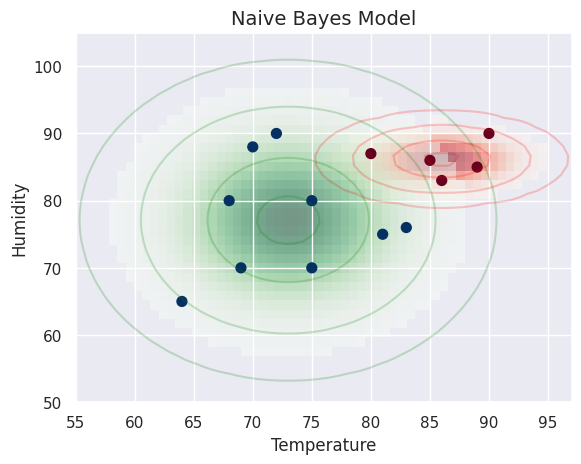

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

fig, ax = plt.subplots()
ax.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='RdBu')
ax.set_title('Naive Bayes Model', size=14)

xlim = (55, 97)
ylim = (50, 105)

xg = np.linspace(xlim[0], xlim[1], 60)
yg = np.linspace(ylim[0], ylim[1], 40)
xx, yy = np.meshgrid(xg, yg)
Xgrid = np.vstack([xx.ravel(), yy.ravel()]).T

for label, color in enumerate(['red', 'green']):
    mask = (y == label)
    mu, std = X[mask].mean(0), X[mask].std(0)
    P = np.exp(-0.5 * (Xgrid - mu) ** 2 / std ** 2).prod(1)
    Pm = np.ma.masked_array(P, P < 0.03)
    # ax.pcolorfast(xg, yg, Pm.reshape(xx.shape), alpha=0.5, cmap=color.title() + 's')
    C = Pm.reshape(xx.shape)  # (ny, nx)

    xedges = np.linspace(xlim[0], xlim[1], C.shape[1] + 1)
    yedges = np.linspace(ylim[0], ylim[1], C.shape[0] + 1)

    ax.pcolorfast(xedges, yedges, C, alpha=0.5, cmap=color.title() + 's')
    ax.contour(xx, yy, P.reshape(xx.shape), levels=[0.01, 0.1, 0.5, 0.9],colors=color, alpha=0.2)

ax.set(xlim=xlim, ylim=ylim)
plt.xlabel('Temperature')
plt.ylabel('Humidity')
plt.show()

In [32]:
print('Play tennis?:', GNB.predict([[80, 86]]))
print('Probabilities:', GNB.predict_proba([[80, 86]]))

Play tennis?: ['no']
Probabilities: [[0.73987326 0.26012674]]
